# Bearing Fault Diagnosis (UORED-VAFCLS) — Akida Benchmark

<p align="right">
Run Time: ~5 minutes
</p>

This notebook evaluates and benchmarks the bearing fault detector on Akida 1 hardware.

For the dataset, the evaluation protocol and how the model was prepared, see the
neighbouring [README.md](README.md) and
[uored_vafcls_notebook_training.ipynb](uored_vafcls_notebook_training.ipynb).

> **Note:** the hardware sections below need a physical AKD1500 device, and the power
> measurements read an INA219 over I2C. Everything is guarded, so the notebook runs
> end-to-end without a board — the hardware cells simply skip. It will not produce
> hardware numbers in Colab.

## Model

A pretrained Akida model is included in this repo, at
`pretrained_models/akdcnn_uored_vafcls_qat.fbz`, trained on bearing-disjoint
**fold 42**. As with all model files here, it is handled via `git-lfs`. If you have
not set that up yet, see the [Trained models](../../../README.md#trained-models)
section of the top-level README.

Latency, power and sparsity are properties of the architecture and its inputs, so they
barely depend on which fold the model was trained on. Its diagnostic accuracy does
depend on the fold, which is why the README reports a 100-fold cross-validation mean
for that.

To benchmark a model you trained yourself, change `MODELS_DIR` in the next cell to
`./models/`.

In [1]:
import json
import os
import sys
import time

import akida
import numpy as np
from tqdm import tqdm

os.environ.setdefault('TF_CPP_MIN_LOG_LEVEL', '1')

# Repo root on sys.path so `brainchip_utils` imports work even when the package
# has not been pip-installed.
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..'))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

DATA_PATH = './data/uored_vafcls'
MODELS_DIR = './pretrained_models/'
MODEL_FILENAME = 'akdcnn_uored_vafcls_qat.fbz'
akida_model_path = os.path.join(MODELS_DIR, MODEL_FILENAME)

# Windows used for the sparsity measurement and every benchmark below, matching
# uored_vafcls_benchmark.py. Power is sampled only every few tens of
# milliseconds, so each benchmark run needs enough inferences to span several
# readings.
NUM_SAMPLES = 100

SEED = 0

# The published figures, for comparison with what this run measures.
with open('docs/metrics.json') as f:
    published = json.load(f)

To load the model, we simply pass the path to the `.fbz` file to `akida.Model()`:

In [2]:
akida_model = akida.Model(akida_model_path)
akida_model.summary()

                 Model Summary                  
________________________________________________
Input shape    Output shape  Sequences  Layers
[300, 140, 1]  [1, 1, 4]     1          9     
________________________________________________

_________________________________________________________
Layer (type)            Output shape   Kernel shape    

========== SW/stem_conv-predictions (Software) ==========

stem_conv (InputConv.)  [147, 67, 16]  (7, 7, 1, 16)   
_________________________________________________________
block1_conv (Conv.)     [74, 34, 32]   (3, 3, 16, 32)  
_________________________________________________________
block2_conv (Conv.)     [37, 17, 64]   (3, 3, 32, 64)  
_________________________________________________________
block3_conv (Conv.)     [19, 9, 64]    (3, 3, 64, 64)  
_________________________________________________________
block4_conv (Conv.)     [10, 5, 64]    (3, 3, 64, 64)  
_________________________________________________________
block5_conv (C

## Dataset

Evaluation runs on the bearings **held out** by fold 42: 8 of the 20 bearings, none of
which the model saw during training. Each 10 s recording is tiled into 1 s windows,
encoded as uint8 and framed to 300 × 140 × 1, exactly as in training (see the
[training notebook](uored_vafcls_notebook_training.ipynb) for what that framing means).

> **First run:** the prepared dataset (~100 MB) downloads automatically from the
> BrainChip data mirror.

In [3]:
from uored_vafcls_data import FIXED_FOLD, INPUT_SHAPE, get_data, get_samples

_, test_ds = get_data(DATA_PATH, INPUT_SHAPE, fold=FIXED_FOLD, seed=SEED)

2026-10-08 16:38:35.673707: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1791470315.686664  535829 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1791470315.690637  535829 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1791470315.700519  535829 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1791470315.700533  535829 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1791470315.700535  535829 computation_placer.cc:177] computation placer alr

Fold 42: holding out bearings [1, 2, 8, 9, 11, 12, 17, 18]
Train: 36 recordings from 12 bearings [3, 4, 5, 6, 7, 10, 13, 14, 15, 16, 19, 20] (Ball 6, Cage 6, Healthy 12, Inner 6, Outer 6)
Held out: 24 recordings from 8 bearings [1, 2, 8, 9, 11, 12, 17, 18] (Ball 4, Cage 4, Healthy 8, Inner 4, Outer 4)
Train and held out share 0 of 20 bearings -> leakage-free


2026-10-08 16:38:38.068144: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## Evaluation of Akida Model

We first check that the model gives the same results on hardware as it did in the
software backend. If an Akida 1 device is connected it is used for inference; if not,
the code falls back to the software backend, a bit-accurate simulation of the hardware.

### Check for a connected Akida hardware device

`akida.devices()` returns the connected devices, or an empty list if there are none.

In [4]:
devices = akida.devices()
print(f'Devices found: {[d.desc for d in devices]}')

Devices found: ['PCIe/AKD1500/16MB/0']


More carefully, we want a device of the right version for this model (Akida IP
version 1). The helper in
[brainchip_utils/hardware_utils.py](../../../brainchip_utils/hardware_utils.py) checks
that.

Having found a matching device, `map` schedules the model onto it. `hw_only=True`
refuses to fall back to software for any layer, so if this succeeds, the whole network
really is running on the chip.

In [5]:
from brainchip_utils.hardware_utils import get_akida_device

device = get_akida_device(target_version=akida_model.ip_version)
if device is not None:
    akida_model.map(device, mode=akida.MapMode.AllNps, hw_only=True)
    print(f'Mapped onto {device.desc}')
else:
    print('No Akida 1 device found: using the software backend.')

Target Akida device found


Mapped onto PCIe/AKD1500/16MB/0


### Run Evaluation on Akida

The Akida runtime takes numpy arrays, so we iterate over the `tf.data` batches. That
is only because the dataset is delivered in TensorFlow format; in a deployment,
windows would be cut from the accelerometer stream and sent to Akida directly.

The model has four independent outputs, one per fault label. We keep the raw outputs
and score them with **macro AUROC**, the same helper the evaluation script uses.

In [6]:
from uored_vafcls_eval import auroc_scores, report

logits_all, labels_all = [], []
for x_batch, y_batch in tqdm(test_ds, desc='Evaluating on Akida'):
    logits_all.append(akida_model.predict(x_batch.numpy()).squeeze(axis=(1, 2)))
    labels_all.append(y_batch.numpy())

scores = auroc_scores(np.concatenate(logits_all), np.concatenate(labels_all))
backend = 'hardware' if device is not None else 'software backend'
report(scores, f'Akida model ({backend}), fold {FIXED_FOLD} held-out')

Evaluating on Akida:   0%|          | 0/2 [00:00<?, ?it/s]

Evaluating on Akida:  50%|█████     | 1/2 [00:00<00:00,  2.34it/s]

Evaluating on Akida: 100%|██████████| 2/2 [00:00<00:00,  2.38it/s]

Evaluating on Akida: 100%|██████████| 2/2 [00:00<00:00,  2.37it/s]


Akida model (hardware), fold 42 held-out macro AUROC: 0.9004
Per-label AUROC:
  inner  0.9238
  outer  0.9925
  ball   1.0000
  cage   0.6854


### Activation Sparsity

Akida skips computation for zero-valued activations, so activation sparsity directly
reduces energy and latency. It has to be measured on real inputs: these windows come
from fold 42's *training* recordings, never the held-out ones.

In [7]:
from akida_models.sparsity import compute_sparsity
from brainchip_utils.plot_utils import pretty_print_sparsity

samples = get_samples(DATA_PATH, INPUT_SHAPE, num_samples=NUM_SAMPLES,
                      fold=FIXED_FOLD, seed=SEED)
sparsity_dict = compute_sparsity(akida_model, samples=samples)
pretty_print_sparsity(sparsity_dict)

print(f'\nMean activation sparsity over {NUM_SAMPLES} windows: '
      f'{np.mean(list(sparsity_dict.values())) * 100:.2f}%')


Layer           Sparsity
------------------------
stem_conv        35.71%
block1_conv      38.08%
block2_conv      35.24%
block3_conv      38.39%
block4_conv      40.37%
block5_conv      39.39%
block6_conv      61.75%
fc               57.30%
predictions       0.00%
------------------------
Mean             38.47%

Mean activation sparsity over 100 windows: 38.47%


## Hardware Benchmark

**These cells require a physical AKD1500 device.** If no device was found above, they
skip cleanly.

Akida is event-driven: computation scales with the number of non-zero activations, not
with tensor size. Benchmark results are therefore *input-dependent*, and random or
synthetic inputs would give misleading timings. The `samples` array above holds real
windows, and is the right input to benchmark with.

### Simple Benchmark

The simplest way to time an Akida model is to call `forward` in a loop and read two
clocks after each inference:

- **System clock** (`time.perf_counter_ns`): wall time, including Python overhead and
  the PCIe transfer.
- **On-chip clock** (`akida_model.metrics['inference_clk']`): clock cycles counted by
  the AKD1500 itself. Dividing by the 400 MHz core frequency gives the compute time.

The two should agree closely; a large gap would point to a transfer or driver
bottleneck rather than a slow model. A priming inference loads the weights onto the
device before timing starts.

In [8]:
CLOCK_FREQUENCY = 400e6  # 400 MHz for AKD1500

if device is not None:
    akida_model.map(device, mode=akida.MapMode.Minimal, hw_only=True)
    akida_model.forward(samples[:2])   # priming: load the model onto the device

    inf_clks, inf_times = [], []
    for i in range(len(samples)):
        start_t = time.perf_counter_ns()
        akida_model.forward(samples[i:i + 1], batch_size=1)
        inf_times.append(time.perf_counter_ns() - start_t)
        inf_clks.append(akida_model.metrics['inference_clk'])

    print(f'Mean inference time (system clock):      {np.mean(inf_times) * 1e-6:.3f} ms')
    print(f'Mean on-chip time (chip clock cycles):   '
          f'{np.mean(inf_clks) / CLOCK_FREQUENCY * 1e3:.3f} ms')

Mean inference time (system clock):      9.931 ms
Mean on-chip time (chip clock cycles):   9.828 ms


### Full Model Benchmark

`full_model_benchmark` from
[brainchip_utils/hardware_utils.py](../../../brainchip_utils/hardware_utils.py) runs the
same timed loop while sampling the INA219 power meter in a separate process. It sweeps
three mapping modes:

- **`Minimal`**: the fewest Neural Processors (NPs) that hold the model.
- **`AllNps`**: the model spread over more NPs, without adding passes.
- **`HwPr`** (Hardware Partial Reconfiguration): the model split into several passes,
  so each layer can use more NPs, at the cost of reloading weights between passes on
  every inference.

The `num_sequences` check matters: more than one sequence would mean part of the model
is running in software, and the timings would be meaningless.

In [9]:
from brainchip_utils.hardware_utils import full_model_benchmark, get_mapping_stats

if device is not None:
    full_results = {}
    for mm in ['Minimal', 'AllNps', 'HwPr']:
        map_mode = getattr(akida.MapMode, mm)
        print(f'Running full-model benchmark (MapMode={mm})...')
        full_results[mm] = full_model_benchmark(akida_model, device, samples,
                                                map_mode=map_mode, repeats=10)

        # Re-map without hw_only to populate akida_model.sequences for stats
        akida_model.map(device, mode=map_mode)
        num_nps, num_passes, num_sequences = get_mapping_stats(akida_model)
        full_results[mm]['num_nps'] = num_nps
        full_results[mm]['num_passes'] = num_passes
        print(f'  Mapping: {num_nps} NP(s), {num_passes} pass(es), {num_sequences} sequence(s)')
        if num_sequences > 1:
            print('WARNING: model not completely mapped to hardware')

Running full-model benchmark (MapMode=Minimal)...
Checking I2C power measurement hardware...


  I2C INA sensor detected — power measurement enabled.


  Supply voltage: 0.805 V

  Power measurement active.
  Repeat 1/10: recording floor (1.0 s)...


  Repeat 1/10 done.
  Repeat 2/10: recording floor (1.0 s)...


...

  Repeat 8/10 done.
  Repeat 9/10: recording floor (1.0 s)...


  Repeat 9/10 done.
  Repeat 10/10: recording floor (1.0 s)...


  Power process: 1659 ok, 0 errors

  Repeat 10/10 done.

  Mean inference time:    8.277 ms  (σ=0.356 ms)
  Mean on-chip time:      7.653 ms  (3061348 clocks)
  Total inferences run:   1000
  Avg dynamic power:      103.8 mW
  Avg dynamic energy:     0.859 mJ/inf


  Mapping: 64 NP(s), 3 pass(es), 1 sequence(s)


Below, this run's numbers next to the published ones from `docs/metrics.json`. Expect
small run-to-run differences in power and latency; cycle counts and the mapping should
match.

In [10]:
if device is not None:
    rows = [('NPs', 'nps', lambda r: f'{r["num_nps"]}'),
            ('passes', 'passes', lambda r: f'{r["num_passes"]}'),
            ('cycles', 'cycles', lambda r: f'{r["mean_inf_clk"]:.0f}'),
            ('on-chip latency (ms)', 'latency_ms', lambda r: f'{r["mean_clk_ms"]:.3f}'),
            ('total energy (mJ/inf)', 'total_E',
             lambda r: f'{r["power"]["avg_energy_mj"]:.3f}' if r['power'] else 'n/a')]
    print(f'{"this run / published":<24}' + ''.join(f'{mm:>22}' for mm in full_results))
    for label, key, fmt in rows:
        cells = [f'{fmt(full_results[mm])} / {published[mm.lower() + "_" + key]}'
                 for mm in full_results]
        print(f'{label:<24}' + ''.join(f'{c:>22}' for c in cells))

this run / published                   Minimal                AllNps                  HwPr
NPs                                    17 / 17               27 / 27               64 / 64
passes                                   1 / 1                 1 / 1                 3 / 3
cycles                       3931700 / 3930879     2933311 / 2932933     3061348 / 3063152
on-chip latency (ms)             9.829 / 9.827         7.333 / 7.332         7.653 / 7.658
total energy (mJ/inf)            1.793 / 1.782         1.515 / 1.506         1.811 / 1.791


The plot shows one column per mapping mode: a power trace (if a power meter is
connected) and the hardware mapping layout.

The model fits in a single pass. `AllNps` spreads it over more NPs within that pass,
and it runs noticeably faster for about the same dynamic energy: more power, for less
time. `HwPr` splits it into three passes so that each layer can use more NPs, but the
weights then have to be reloaded between passes on every inference. For a model this
small that overhead outweighs the per-layer gain, so `HwPr` is slower than `AllNps`
and costs more energy. It is the better choice for most larger models, which is why
it is benchmarked here at all.


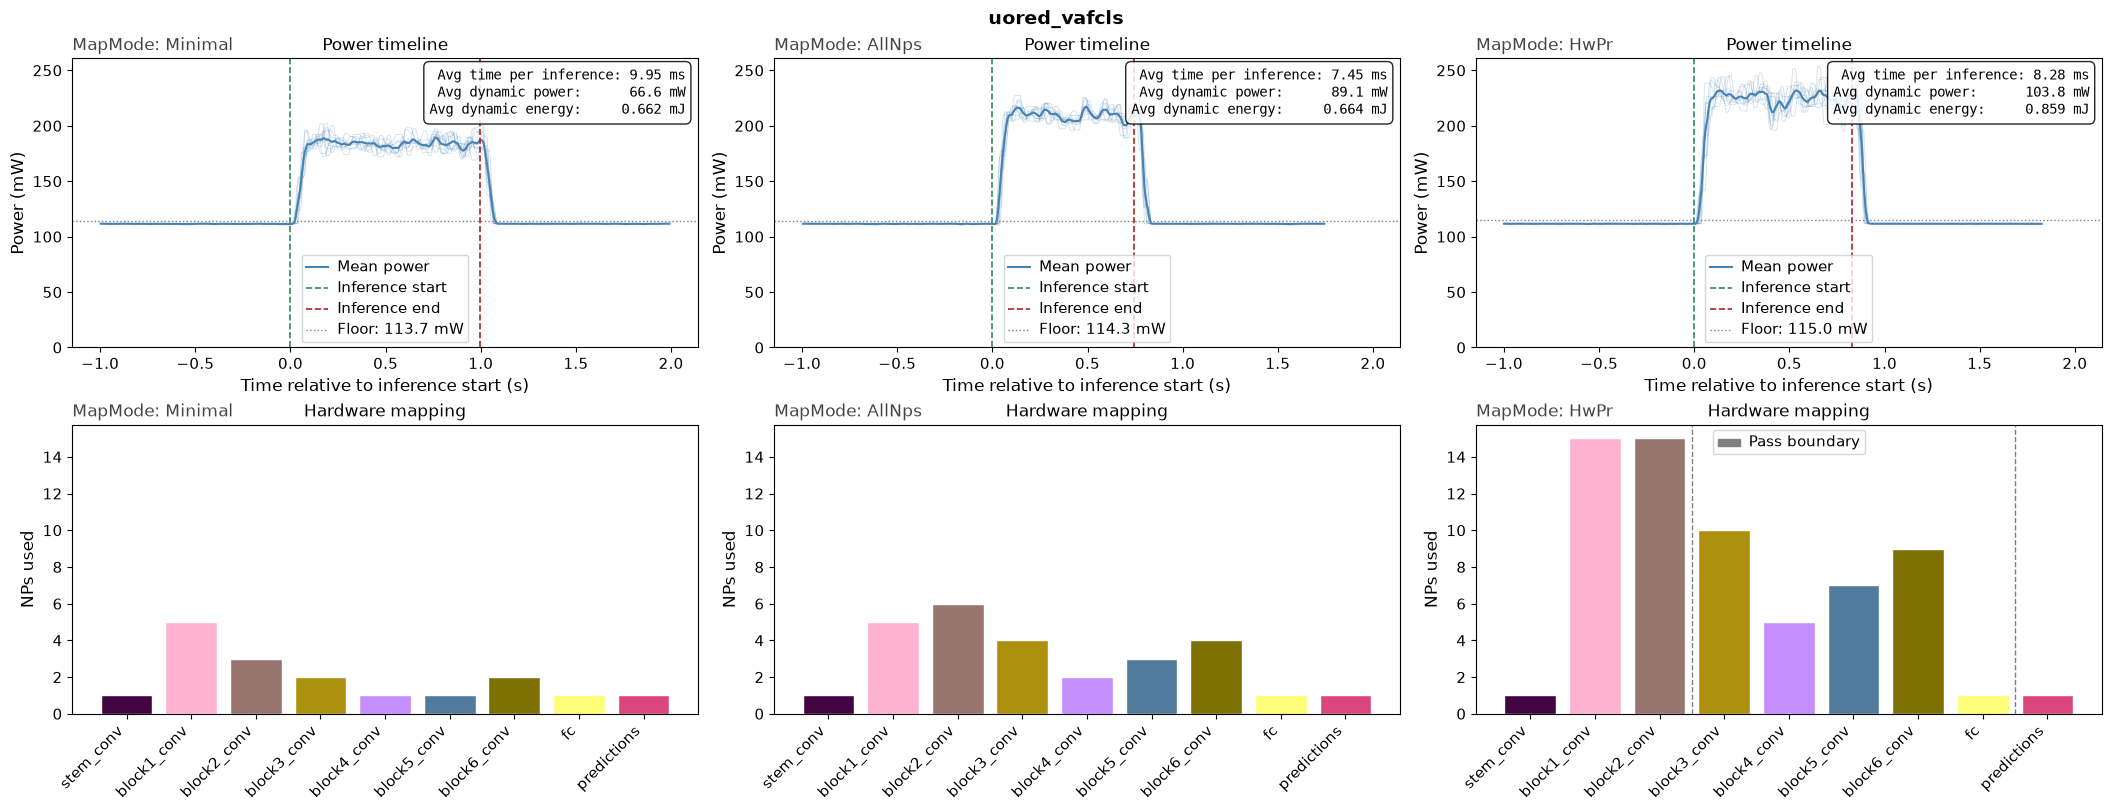

In [11]:
from brainchip_utils.plot_utils import plot_full_model_results

if device is not None:
    plot_full_model_results(full_results, akida_model, device, model_name='uored_vafcls')

### Per-Layer Benchmark

Full-model timing gives the total cost but not where the time goes.
`per_layer_benchmark` reconstructs latency layer by layer, by running cumulative
sub-models and differencing the results.

A layer's cost depends on how much input it receives, its number of filters, its type
and kernel size, and how many NPs it is spread over. On Akida there is one more factor:
the standard NPs process *events* (non-zero activations), so a layer's cost also scales
with its **input** density. The input layer is the exception, as the next section
explains. The plot shows input sparsity per layer alongside latency, so the two can be
read together.

Running per-layer benchmark (100 samples)...



Layer           Latency (ms)       Clocks
---------------------------------
stem_conv             3.1605
block1_conv           1.2068
block2_conv           2.0409
block3_conv           1.6379
block4_conv           0.8191
block5_conv           0.3413
block6_conv           0.1173
fc                    0.4952
predictions           0.0096
---------------------------------
Total                 9.8285


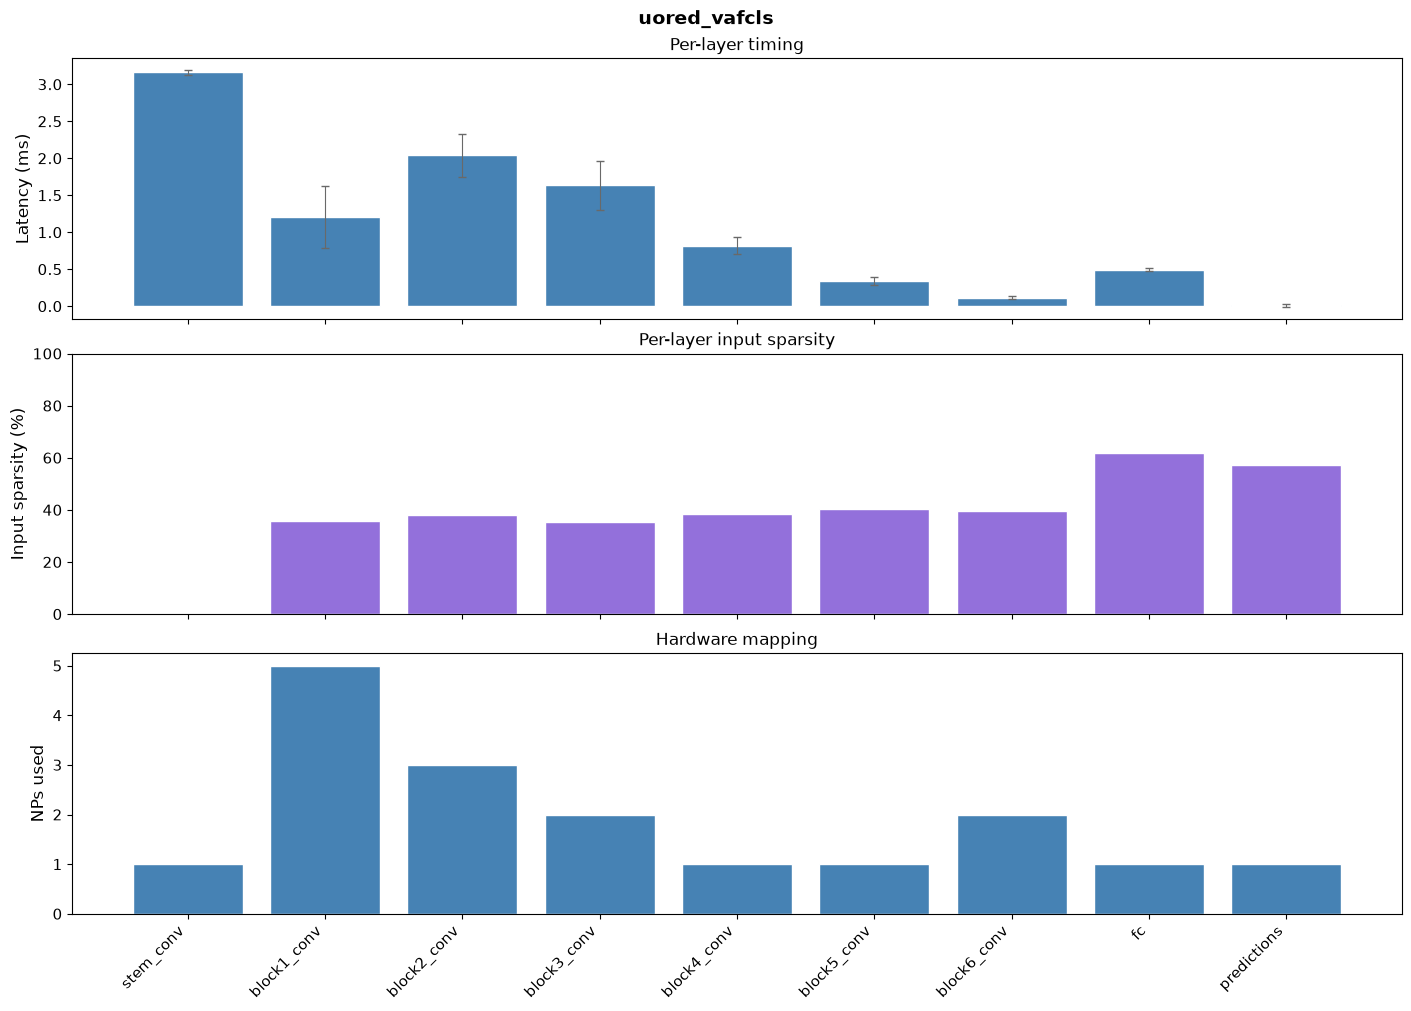

In [12]:
from brainchip_utils.hardware_utils import per_layer_benchmark
from brainchip_utils.plot_utils import plot_per_layer_results

if device is not None:
    # Map without hw_only so akida_model.sequences is populated for the plot
    akida_model.map(device, mode=akida.MapMode.Minimal)
    print(f'Running per-layer benchmark ({len(samples)} samples)...')
    per_layer_results = per_layer_benchmark(akida_model, device, samples,
                                            repeats=len(samples))
    plot_per_layer_results(per_layer_results, akida_model, sparsity_dict,
                           model_name='uored_vafcls')

The stem convolution is the slowest layer here, and it is not like the others. It is
Akida 1's input layer
([`InputConvolutional`](https://doc.brainchipinc.com/api_reference/akida_apis.html#akida.InputConvolutional)
in the Akida API), which runs on a dedicated input processor rather than on a standard
NP. It counts as one NP in the mapping statistics, but it is a separate unit, designed
for dense image input: it takes 8-bit inputs with 1 or 3 channels, and it is a
conventional convolution that does **not** exploit sparsity.

In most image models that layer does little of the work, because its input has only a
few channels and it has few filters. Here it is the slowest layer because it runs a
7 × 7 kernel over the full 300 × 140 input. The pooling after each block then shrinks the
spatial size faster than the filter count grows, so the later layers have far less to
compute, and the first few of them are also split across several NPs. The input layer
is a single dedicated unit, so no mapping mode can spread it out, and that caps what
`AllNps` or `HwPr` can gain for this model.
